In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

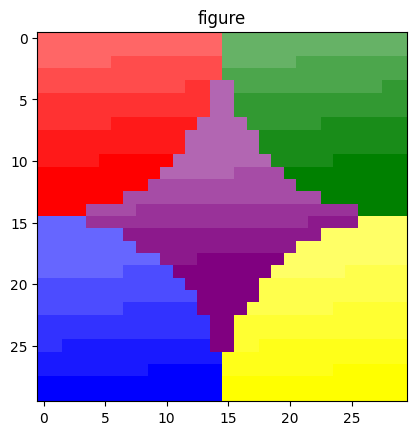

In [5]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

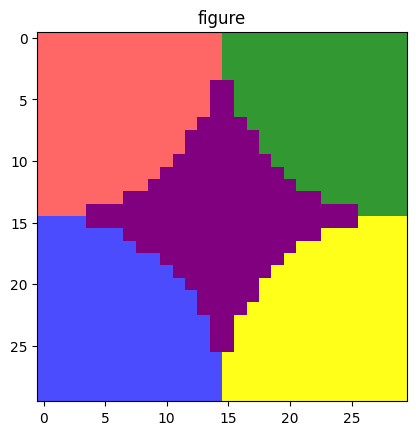

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

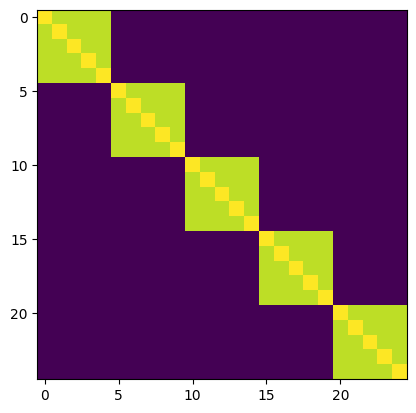

In [7]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.45)
plt.imshow(R)


covariance across tasks G

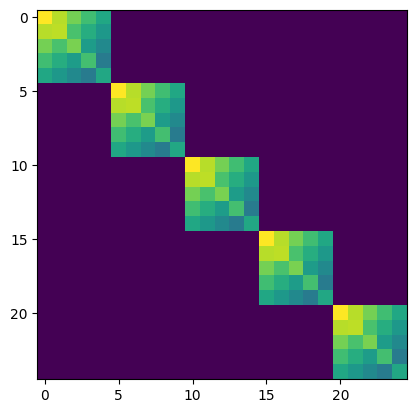

In [8]:
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=[1.0, 0.9,0.8, 0.7, 0.6])
plt.imshow(G)

make Vs (this num_iter gives a good V)

17.613652168263002
15.202629408012863
15.171034613279941
14.651788280270802
14.550428466507402
14.271245668305681
14.268131317850955
14.194719035643718


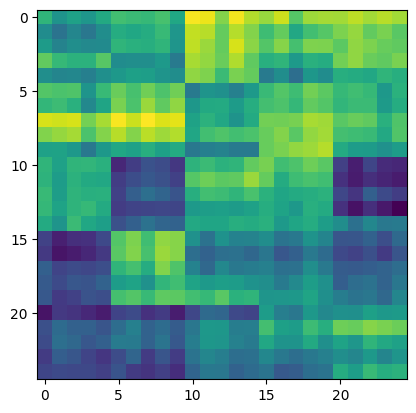

In [9]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

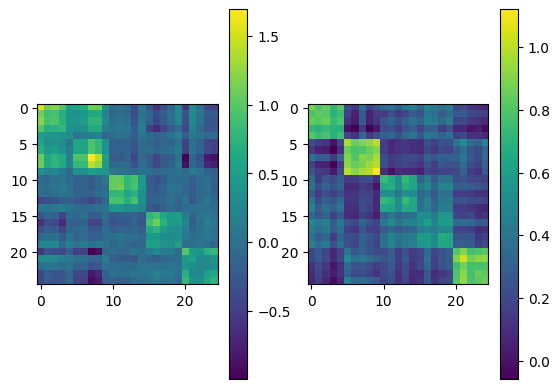

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.show()


lower dimensional Vs (just for the 5 main parcels)

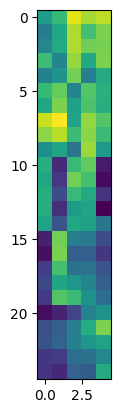

In [11]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [12]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

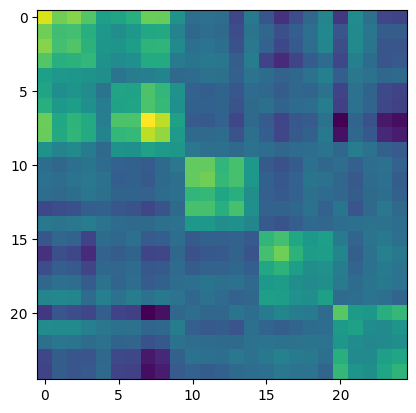

In [13]:
G_lib  = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [14]:
D = ut.build_combinations(G_lib, strategy='random',n_iter=50000,n_tasks=8,seed=503)
D_ev = ev.evaluate_dataframe_simulation_singleregion(D,Y_true, Vs_5, U_true_5,sig_e=0.15,parcel_to_evaluate=1)


building0
building10000
building20000
building30000
building40000
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing combination: 10000
Processing combination: 11000
Processing combination: 12000
Processing combination: 13000
Processing combination: 14000
Processing combination: 15000
Processing combination: 16000
Processing combination: 17000
Processing combination: 18000
Processing combination: 19000
Processing combination: 20000
Processing combination: 21000
Processing combination: 22000
Processing combination: 23000
Processing combination: 24000
Processing combination: 25000
Processing combination: 26000
Processing combination: 27000
Processing combination: 28000
Processing combination: 29000
Processing combination: 30000
Processing combin

In [19]:
n= 2000
results_list = []

n_unique_counts = D_ev['n_unique'].value_counts()
n_unique_filtered = n_unique_counts[n_unique_counts > n].index.sort_values()

for n_unique_val in n_unique_filtered:
    D_ev_single = D_ev[D_ev['n_unique'] == n_unique_val]
    D_ev_single = D_ev_single.sample(n=n, random_state=42)


    X = D_ev_single[['variance', 'log_det', 'inverse_trace']]
    y = D_ev_single['perc'].values

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_standardized = (X - X_mean) / X_std

    # Add intercept 
    ones = np.ones(shape=(X_standardized.shape[0], 1))
    X_design = np.hstack([ones, X_standardized])

    # OLS
    Betas = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

    # get the intercept and coefficients
    intercept = Betas[0]
    coefficients = Betas[1:]
    y_pred = X_design @ Betas

    # Calculate R-squared
    residuals = y - y_pred
    SS_res = np.sum(residuals ** 2)
    SS_tot = np.sum((y - y.mean()) ** 2)
    R_squared = 1 - (SS_res / SS_tot)

    result = {
        'n_unique': n_unique_val,
        'intercept': intercept,
        'variance_coef': coefficients[0],
        'log_det_coef': coefficients[1],
        'inverse_trace_coef': coefficients[2],
        'R_squared': R_squared
    }
    results_list.append(result)


results_df = pd.DataFrame(results_list)





<Axes: xlabel='n_unique', ylabel='Value'>

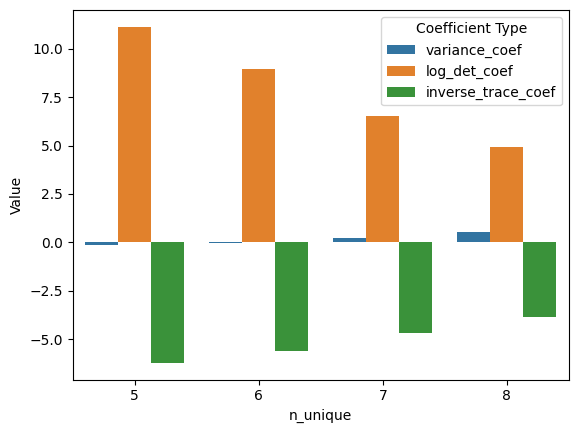

In [20]:
df_melted = results_df.melt(id_vars=["n_unique", "R_squared"], 
                    value_vars=["variance_coef", "log_det_coef", "inverse_trace_coef"], 
                    var_name="Coefficient Type", 
                    value_name="Value")
sns.barplot(data=df_melted, x="n_unique", y="Value", hue="Coefficient Type")




<Axes: xlabel='n_unique', ylabel='R_squared'>

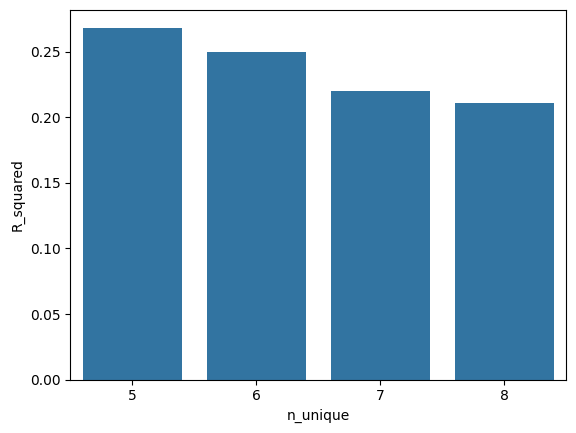

In [17]:
sns.barplot(data=results_df, x="n_unique", y="R_squared")